In [53]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from lmfit import Minimizer, Parameters
import seaborn as sns
from rich.progress import track

sns.set(color_codes=True, style="white")

## Load Data

In [54]:
# folder = "/Users/esumrall/Desktop/RNA-in-HOPS_condensates/THOR_and_THORdel_1x_2x"
folder = "/Volumes/lsa-nwalter/Sam_Husna_turbo/Data/HOPS-RNA-project/paper_figure_plots/Effect_RBP_binding_THOR"
os.chdir(folder)

color_map = {
    '1x':    "#e33228",
    '1xdel': "#FF758F",
    '2x':    "#398bc3",
    '2xdel': "#90e0ef",
}

file_map = {
    '1x':    "colocalization_AIO_concat-THOR_1x_100ms.csv",
    '1xdel': "colocalization_AIO_concat-THORdel_1x_100ms.csv",
    '2x':    "colocalization_AIO_concat-THOR_2x_100ms.csv",
    '2xdel': "colocalization_AIO_concat-THORdel_2x_100ms.csv",
}

conditions_label = [
    r"iso, THOR",
    r"iso, THOR$\Delta$",
    r"hyp, THOR",
    r"hyp, THOR$\Delta$",
    r"iso, THOR",
    r"iso, THOR$\Delta$",
    r"hyp, THOR",
    r"hyp, THOR$\Delta$",   
]

In [55]:
# Read all dataframes
dfs = {k: pd.read_csv(v) for k, v in file_map.items()}

## Functions

In [56]:
def get_dwell_times(condensate_flag, track_ids):
    # Identify segment boundaries
    change_c = np.where(condensate_flag[:-1] != condensate_flag[1:])[0] + 1
    change_t = np.where(track_ids[:-1] != track_ids[1:])[0] + 1
    boundaries = np.unique(np.concatenate((change_c, change_t)))
    boundaries = np.concatenate(([0], boundaries, [len(condensate_flag)]))
    # Extract dwell durations
    dwell_list = []
    for i in range(len(boundaries) - 1):
        start = boundaries[i]
        if condensate_flag[start]:
            end = boundaries[i + 1]
            dwell_list.append(end - start)
    return np.array(dwell_list)


def calc_R2(y, y_fit):
    resid = y - y_fit
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y - y.mean())**2)
    return 1 - (ss_res / ss_tot)


def cdf_residuals(params, t, cdf_data):
    a1 = params['a1']
    a2 = 1 - a1
    tau1 = params['tau1']
    tau2 = params['tau2']
    model = 1 - a1 * np.exp(-t / tau1) - a2 * np.exp(-t / tau2)
    return model - cdf_data


def fit_dual_exponential(dwell_times, pct=0.99):
    # Remove extreme outliers beyond the given percentile
    cutoff = np.quantile(dwell_times, pct)
    dt_filtered = dwell_times[dwell_times <= cutoff]

    # Build CDF
    bins, brange = 100, (0.1, 3)
    hist, edges = np.histogram(dt_filtered, bins=bins, range=brange, density=True)
    cdf = np.cumsum(hist) / hist.sum()
    t = edges[:-1] + brange[1] / bins

    # Set up parameters
    params = Parameters()
    params.add('a1',  min=0, max=1, value=0.5)
    params.add('tau1', min=0.03, max=0.5, value=0.1)
    params.add('tau2', min=0.5,  max=2.0, value=1.0)

    # Fit
    minner = Minimizer(cdf_residuals, params, fcn_args=(t, cdf))
    result = minner.minimize()

    # Calculate fitted CDF and R²
    fitted = cdf + result.residual
    R2 = calc_R2(cdf, fitted)

    return {
        't':      t,
        'cdf':    cdf,
        'fitted': fitted,
        'a1':     result.params['a1'].value,
        'a2':     1 - result.params['a1'].value,
        'tau1':   result.params['tau1'].value,
        'tau2':   result.params['tau2'].value,
        'a1_se':  result.params['a1'].stderr,
        'tau1_se':result.params['tau1'].stderr,
        'tau2_se':result.params['tau2'].stderr,
        'R2':     R2,
        'cutoff': cutoff,
    }


def count_dwell_events(condensate_flag, track_ids):
    change_c = np.where(condensate_flag[:-1] != condensate_flag[1:])[0] + 1
    change_t = np.where(track_ids[:-1] != track_ids[1:])[0] + 1
    boundaries = np.unique(np.concatenate((change_c, change_t)))
    boundaries = np.concatenate(([0], boundaries, [len(condensate_flag)]))
    # Track boundaries for counting
    t_changes = np.where(track_ids[:-1] != track_ids[1:])[0] + 1
    t_bounds = np.concatenate(([0], t_changes, [len(track_ids)]))
    counts = []
    for i in range(len(t_bounds)-1):
        mask = (change_c >= t_bounds[i]) & (change_c <= t_bounds[i+1])
        counts.append(mask.sum())
    return np.array(counts)

## Process all conditions

In [57]:
dwell_data = {}
fit_results = {}

for key, df in dfs.items():
    dt_raw = get_dwell_times(df['InCondensate'].to_numpy(),
                             df['RNA_trackID'].to_numpy()) * 0.1
    dwell_data[key] = dt_raw
    fit_results[key] = fit_dual_exponential(dt_raw, pct=0.99)

## Plot CDF with dual-exponential fit

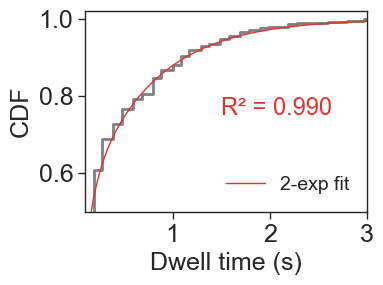

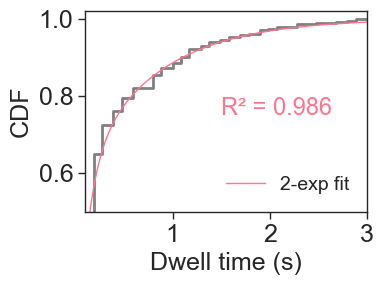

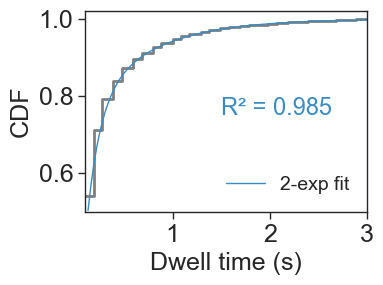

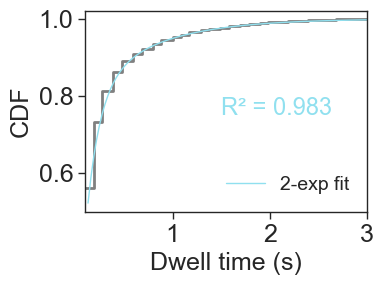

In [58]:
labels = {
    '1x':    "iso, THOR",
    '1xdel': "iso, THOR\u0394",
    '2x':    "hyp, THOR",
    '2xdel': "hyp, THOR\u0394",
}

for key, res in fit_results.items():
    plt.figure(figsize=(4, 3))
    # Empirical CDF
    sns.histplot(
        data=dwell_data[key],
        bins=100, binrange=(0.1, 3),
        stat='probability', cumulative=True,
        element='step', fill=False, color='gray', lw=2
    )
    # Dual-exponential fit
    plt.plot(res['t'], res['fitted'],
             color=color_map[key], linestyle='-', lw=1, label='2-exp fit')
    # Annotation
    plt.text(1.5, 0.75,
             f"R² = {res['R2']:.3f}",
             fontsize=17, color=color_map[key])
    plt.xlabel("Dwell time (s)", fontsize=18)
    plt.ylabel("CDF", fontsize=18)
    # plt.title(labels[key], fontsize=18)
    plt.xlim(0.1, 3)
    plt.ylim(0.5, 1.02)
    ax = plt.gca()
    ax.spines[:].set_linewidth(1)
    ax.tick_params(axis='both', which='major',
                   labelsize=18, direction='out',
                   length=5, width=1,
                   bottom=True, left=True)
    
    plt.legend(frameon=False, loc=4, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"compare_dualexp_{key}.svg", dpi=300, bbox_inches='tight', format='svg')
    plt.show()


## Interaction frequency analysis

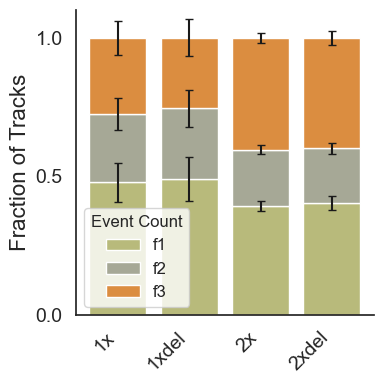

In [59]:
N_events = {k: count_dwell_events(
                dfs[k]['InCondensate'].to_numpy(),
                dfs[k]['RNA_trackID'].to_numpy())
            for k in dfs}

def bootstrap_event_fractions(arr, pct=0.3, nboot=1000):
    arr = arr[arr > 0]
    n = int(len(arr) * pct)
    f1_list, f2_list, f3_list = [], [], []
    for _ in range(nboot):
        samp = np.random.choice(arr, size=n, replace=True)
        f1_list.append((samp == 1).sum() / n)
        f2_list.append(((samp > 1) & (samp <= 3)).sum() / n)
        f3_list.append((samp > 3).sum() / n)
    def compute_stats(lst):
        mean = np.mean(lst)
        sem = (np.percentile(lst, 95) - np.percentile(lst, 5)) / 2
        return mean, sem
    return (*compute_stats(f1_list), *compute_stats(f2_list), *compute_stats(f3_list))

# Gather bootstrap fractions
fractions = {k: bootstrap_event_fractions(v) for k, v in N_events.items()}

# Build DataFrame for plotting stacked bar
df_frac = pd.DataFrame.from_dict({
    k: {
        'f1_mean': v[0], 'f1_sem': v[1],
        'f2_mean': v[2], 'f2_sem': v[3],
        'f3_mean': v[4], 'f3_sem': v[5],
    } for k, v in fractions.items()
}).T

# Plot stacked bar chart
plt.figure(figsize=(4, 4))
x = np.arange(len(df_frac))
bottom = np.zeros(len(df_frac))
colors = ["#B8BA7B", "#A6A896", "#DB8D40"]
categories = ['f1', 'f2', 'f3']

for i, cat in enumerate(categories):
    plt.bar(
        x, df_frac[f'{cat}_mean'],
        yerr=df_frac[f'{cat}_sem'], capsize=3,
        bottom=bottom, color=colors[i], label=cat
    )
    bottom += df_frac[f'{cat}_mean']

plt.ylim(0, 1.1)
plt.xticks(x, df_frac.index, rotation=45, ha='right', fontsize=14)
plt.yticks([0, 0.5, 1], fontsize=14)
plt.ylabel("Fraction of Tracks", fontsize=16)
plt.legend(title="Event Count", fontsize=12)
plt.gca().spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig("stacked_event_fractions.svg", dpi=300, bbox_inches='tight', format='svg')
plt.show()

## Dual-exponential $\tau$ and fraction errorbar plots

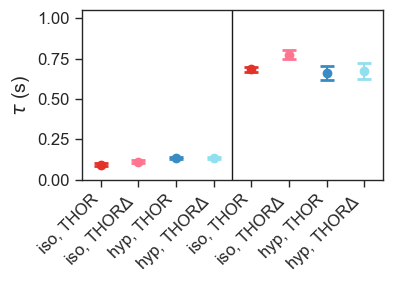

In [66]:
# Mapping keys to descriptive labels and colors
labels_full = {
    '1x':    ("iso, THOR",          color_map['1x']),
    '1xdel': ("iso, THOR\u0394",    color_map['1xdel']),
    '2x':    ("hyper, THOR",        color_map['2x']),
    '2xdel': ("hyper, THOR\u0394",  color_map['2xdel']),
}

# Prepare data for τ errorbar plot (fast then slow for each condition)
conds = list(labels_full.keys())
n = len(conds)
tau_fast = np.array([fit_results[c]['tau1']   for c in conds])
tau_fast_se = np.array([fit_results[c]['tau1_se'] for c in conds])
tau_slow = np.array([fit_results[c]['tau2']   for c in conds])
tau_slow_se = np.array([fit_results[c]['tau2_se'] for c in conds])
colors_full = [labels_full[c][1] for c in conds]

# Build combined lists
lst_tau    = np.concatenate([tau_fast, tau_slow])
lst_tau_se = np.concatenate([tau_fast_se, tau_slow_se])
lst_colors = colors_full * 2
lst_labels = [f"{labels_full[c][0]}, 2-exp [fast]" for c in conds] + \
             [f"{labels_full[c][0]}, 2-exp [slow]" for c in conds]

# τ errorbar plot
plt.figure(figsize=(4, 3))
x_pos = np.arange(len(lst_labels))
plt.axvline((x_pos[n-1] + x_pos[n]) / 2, c='k', lw=1)
for i in range(len(lst_labels)):
    plt.errorbar(
        x_pos[i], lst_tau[i], yerr=lst_tau_se[i],
        fmt='o', capsize=5, capthick=2, color=lst_colors[i]
    )
plt.xticks(x_pos, conditions_label, rotation=45, ha='right', fontsize=12)
plt.xlim(-0.5, len(lst_labels)-0.5)
plt.ylim(0,1.05)
plt.ylabel(r"$\tau$ (s)", fontsize=14)
plt.gca().spines[:].set_linewidth(1)
plt.gca().tick_params(axis='both', which='major', labelsize=12,
                      direction='out', length=5, width=1.0, left=True, bottom=True)
plt.tight_layout()
plt.savefig("doterrorplot_tau_dual.svg", dpi=300, bbox_inches='tight', format='svg', transparent=True)
plt.show()

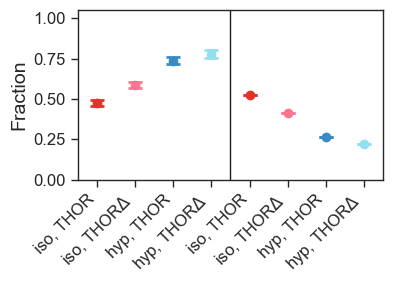

In [67]:
# Prepare data for fraction errorbar plot (a1 then a2)
frac_fast = np.array([fit_results[c]['a1']    for c in conds])
frac_fast_se = np.array([fit_results[c]['a1_se'] for c in conds])
frac_slow = np.array([fit_results[c]['a2']    for c in conds])
frac_slow_se = np.array([fit_results[c]['tau2_se']*0 + fit_results[c]['tau2_se']*0 for c in conds])  # no sem for a2 provided separately

# Build lists
lst_frac    = np.concatenate([frac_fast, frac_slow])
lst_frac_se = np.concatenate([frac_fast_se, frac_slow_se])
# Reuse lst_colors and lst_labels with updated suffixes
lst_labels_frac = [f"{labels_full[c][0]}, 2-exp [fast]" for c in conds] + \
                  [f"{labels_full[c][0]}, 2-exp [slow]" for c in conds]

# Fraction errorbar plot
plt.figure(figsize=(4, 3))

x_pos = np.arange(len(lst_labels_frac))

plt.axvline((x_pos[n-1] + x_pos[n]) / 2, c='k', lw=1)

for i in range(len(lst_labels_frac)):
    plt.errorbar(
        x_pos[i], lst_frac[i], yerr=lst_frac_se[i],
        fmt='o', capsize=5, capthick=2, color=lst_colors[i]
    )

plt.xticks(x_pos, conditions_label, rotation=45, ha='right', fontsize=12)
plt.xlim(-0.5, len(lst_labels_frac)-0.5)
plt.ylim(0,1.05)
plt.ylabel("Fraction", fontsize=14)
plt.gca().spines[:].set_linewidth(1)
plt.gca().tick_params(axis='both', which='major', labelsize=12,
                      direction='out', length=5, width=1, bottom=True, left=True)
plt.tight_layout()
plt.savefig("doterrorplot_frac_dual.svg", dpi=300, bbox_inches='tight', format='svg', transparent=True)
plt.show()